## Deteccion de Anomalías a través de Autoencoders.
### Proyecto Final - Deep Learning
***A. Martín Ramírez Rabelo***

#### Objetivo 

Desarrollar un modelo de detección de anomalías utilizando autoencoders y aplicar este modelo al conjunto de datos Optdigits.

#### Metodología/Contenido

El proyecto se llevará a cabo en cuatro fases principales: 

1. Creación de un modelo de red neuronal profunda para la clasificación inicial. 
2. Implementación de un autoencoder para la detección y eliminación de datos anómalos. 
3. Reclasificación del conjunto de datos purgado de anomalías.
4. Interpretación de resultados, conclusiones y experiencias obtenidas durante el trabajo.

## Conjunto de datos 

El conjunto de datos Optdigits contiene imágenes de dígitos escritos a mano y se puede encontrar en Optdigits Dataset. Este conjunto de datos es adecuado para tareas de clasificación y detección de anomalías debido a su estructura y variedad de clases.
https://odds.cs.stonybrook.edu/optdigits-dataset/

- Cada imagen en el conjunto de datos son dígitos manuscritos (0-9) representados por una cuadrícula de píxeles de 8x8, lo que significa que cada imagen tiene 64 características (8x8=64 píxeles). 

- Cada píxel tiene un valor de intensidad que varía de 0 a 16. 

- En total, el conjunto de datos contiene 5620 ejemplos, divididos en 3823 para entrenamiento y 1797 para prueba. 

- Los dígitos representados en estas imágenes abarcan del 0 al 9, proporcionando un total de 10 clases distintas. 

La variedad en la escritura de los dígitos, debido a diferentes estilos de escritura a mano, agrega un nivel de complejidad que hace que este conjunto de datos sea ideal para probar algoritmos de aprendizaje automático y técnicas de preprocesamiento de imágenes. Además, la detección de anomalías se puede realizar identificando dígitos que no coincidan con ninguna de las clases estándar, lo que puede ser útil en aplicaciones prácticas como la lectura automática de dígitos en documentos escaneados o la verificación de firmas manuscritas.

In [1]:
#Install the ucimlrepo package
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


El conjunto de datos original de reconocimiento óptico de dígitos escritos a mano del repositorio de aprendizaje automático de UCI es un conjunto de datos de clasificación multiclase (10 clases en este caso - dígitos del 0 al 9). Las instancias de los dígitos del 1 al 9 son valores normales (inliers) y las instancias del dígito 0 se reducen a 150 valores atípicos.

- Las instancias del dígito 0 han sido reducidas o "down-sampled" a 150 ejemplos y son tratadas como valores atípicos o "outliers". Los valores atípicos son ejemplos que son menos frecuentes o anómalos en el conjunto de datos. 

- *Repositorio de UCI: Es una base de datos ampliamente utilizada en la comunidad de aprendizaje automático que proporciona acceso a una variedad de conjuntos de datos para la investigación y el desarrollo de modelos de aprendizaje automático.*

A continuación cargamos los datos desde el repositorio oficial y visualizamos algunas de las imágenes. 

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 
  
# data (as pandas dataframes) 
X = optical_recognition_of_handwritten_digits.data.features 
y = optical_recognition_of_handwritten_digits.data.targets 
  
# metadata 
print(optical_recognition_of_handwritten_digits.metadata) 
  
# variable information 
print(optical_recognition_of_handwritten_digits.variables) 

{'uci_id': 80, 'name': 'Optical Recognition of Handwritten Digits', 'repository_url': 'https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits', 'data_url': 'https://archive.ics.uci.edu/static/public/80/data.csv', 'abstract': 'Two versions of this database available; see folder', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 5620, 'num_features': 64, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Wed Aug 23 2023', 'dataset_doi': '10.24432/C50P49', 'creators': ['E. Alpaydin', 'C. Kaynak'], 'intro_paper': {'title': 'Methods of Combining Multiple Classifiers and Their Applications to Handwritten Digit Recognition', 'authors': 'C. Kaynak', 'published_in': 'MSc Thesis, Institute of Graduate Studies in Science and Engineering, Bogazici University', 

In [3]:
X

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,0,6,14,7,1,0,0
1,0,0,10,16,6,0,0,0,0,7,...,3,0,0,0,10,16,15,3,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,0,9,14,0,0,0,0
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,0,1,15,2,0,0
4,0,0,5,14,4,0,0,0,0,0,...,12,0,0,0,4,12,14,7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5615,0,0,4,10,13,6,0,0,0,1,...,4,0,0,0,2,14,15,9,0,0
5616,0,0,6,16,13,11,1,0,0,0,...,1,0,0,0,6,16,14,6,0,0
5617,0,0,1,11,15,1,0,0,0,0,...,0,0,0,0,2,9,13,6,0,0
5618,0,0,2,10,7,0,0,0,0,0,...,2,0,0,0,5,12,16,12,0,0


In [4]:
y

,class
0,0
1,0
2,7
3,4
4,6
...,...
5615,9
5616,0
5617,8
5618,9


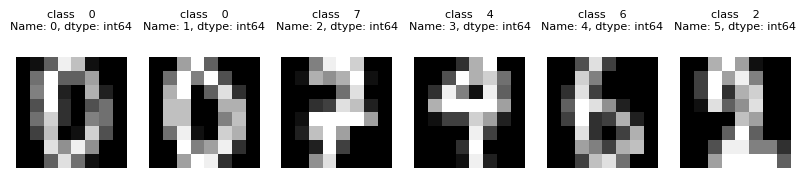

In [5]:
import matplotlib.pyplot as plt

#Vizualización de imágenes
num_images = 6  # Number of images to display
fig, axes = plt.subplots(1, num_images, figsize=(10, 3))

for i in range(num_images):
    # Convertimos cada fila del dataset en una matriz de 8x8.
    image = X.iloc[i].values.reshape(8, 8)
    label = y.iloc[i]
    
    # Graficar imagen
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'{label}', pad=20, fontsize=8)
    axes[i].axis('off')

# Ajustar espacio
plt.subplots_adjust(wspace=0.2)
plt.show()

## Fase 1. 
#### Creación de un modelo de red neuronal profunda para la clasificación inicial.
- Cargamos las librerias y modulos necesarios 


In [6]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
print(torch.cuda.is_available())

True


- Preprocesamiento de los datos para pytorch 
    - Normalizar
    - Conversión tensorial
    - Dividir los datos en entrenamiento, validación y prueba
    - Creación de los DataLoaders

In [7]:
#Establecemos la GPU como dispositivo predeterminado 
device=torch.set_default_device('cuda')

# Normalizar los datos
scaler = StandardScaler()
X = scaler.fit_transform(X)


# Convertir a tensores
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y.to_numpy().flatten(), dtype=torch.long)

# Dividir los datos en entrenamiento, validación y prueba
X_train, X_temp, y_train, y_temp = train_test_split(X_tensor, y_tensor, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Crear DataLoaders
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

- Paso 2: Crear la red neuronal profunda. 

Basado en la práctica anterior, probaré con un modelo de 3 capas con 100 neuronas cada una con funcion de activación PRelu; una variante de ReLU que permite un pequeño gradiente cuando la entrada es negativa.
$$
f(x) = \begin{cases} 
x & \text{si } x > 0 \\
\alpha x & \text{si } x \leq 0 
\end{cases}
$$
 Esta Función de activación tiene algunas ventajas.
- Evita el problema de “dying ReLU”.
- Introduce una pequeña pendiente para gradientes negativos.
- Con Leaky Relu el valor de α debe ajustarse sin embargo con PReLU el valor se aprende durante el entrenamiento.
- Permite que la red aprenda la pendiente óptima.

In [8]:
#Definimos la arquitectura de la red neuronal DNN2
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DeepNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # Primera capa oculta
        self.prelu1 = nn.PReLU()  # Función de activación ReLU para la primera capa
        self.fc2 = nn.Linear(hidden_size, hidden_size)  # Segunda capa oculta
        self.prelu2 = nn.PReLU()  # Función de activación ReLU para la segunda capa
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.prelu3 = nn.PReLU()  # Función de activación ReLU para la segunda capa
        self.fc4 = nn.Linear(hidden_size, output_size)  # Capa de salida
        self.softmax = nn.Softmax(dim=1)  # Función de activación Softmax

    def forward(self, x):
        #x = x.view(-1, input_size)  # Aplanar la entrada
        x = self.fc1(x)
        x = self.prelu1(x)
        x = self.fc2(x)
        x = self.prelu2(x)
        x = self.fc3(x)
        x = self.prelu3(x)
        x = self.fc4(x)
        x = self.softmax(x)
        return x


- Estructura basada en la práctica anterior de la etapa de entrenamiento, validación y evaluación.

In [9]:
def Train_Validate(model, criterion, optimizer, epochs):
 
    #Establecemos variables de control para Early-Stopping
    # Inicializa con un valor alto para minimización (o -inf para maximización)
    #best_val_metric = float('inf')  
    #epochs_sin_mejora = 0 #contador de epocas sin mejora
    #max_epochs_sin_mejora = 5 #Umbral de parada.

    #--------------------------------------------------------------------------------------#
    #-------------------------- Entrenamiento y validación---------------------------------#
    #--------------------------------------------------------------------------------------#
    # Listas vacías para almacenar las métricas de pérdida y exactitud en cada época.
    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    #-----------------------------Ciclo de entrenamiento y validacion-----------------------------#
    for epoch in range(epochs):
        optimizer.zero_grad() #Reinicia los gradientes acumulados en los parámetros del modelo.
        outputs = model(X_train) #Obtiene las predicciones del modelo para el conjunto de entrenamiento.
        loss = criterion(outputs, y_train) #Calcula la pérdida con CrossEntropyLoss.
        train_loss_history.append(loss.item()) #Registra la pérdida en el conjunto de entrenamiento
        #Calcula la exactitud en el conjunto de entrenamiento.
        train_accuracy = (outputs.argmax(dim=1) == y_train).float().mean().item()
        #Registra exactitud en el conjunto de entrenamiento. 
        train_acc_history.append(train_accuracy)  

        loss.backward() #Retropropagación para calcular los gradientes de los parámetros.
        optimizer.step() #Actualiza los pesos del modelo utilizando el optimizador (en este caso, Adam).
        

        #-----------------------Evaluación en el conjunto de validación---------------------------#
        with torch.no_grad(): #Desactiva el cálculo de gradientes para evitar que se modifiquen los pesos del modelo.
            val_outputs = model(X_val) #Obtiene las predicciones del modelo para el conjunto de validación.
            val_loss = criterion(val_outputs, y_val) #Calcula la pérdida con CrossEntropyLoss.
            val_loss_history.append(val_loss.item()) #Registra la pérdida en el conjunto de validación

            _, predicted = torch.max(val_outputs, 1) #Obtiene las etiquetas predichas.
            accuracy = (predicted == y_val).sum().item() / len(y_val) #Calcula la exactitud en el conjunto de validación.
            #.item() se utiliza para obtener el valor numérico de un tensor de PyTorch.
            val_acc_history.append(accuracy) #Registra la exactitud en el conjunto de validación.

        #------------------------------------Early-Stopping-----------------------------------#
        # Calcula la razón entre las pérdidas de entrenamiento y validación (Diferencia porcentual)
        loss_ratio = ((val_loss.item()/ loss.item())-1)*100   
        accuracy_ratio = ((train_accuracy/accuracy)-1)*100 
        #print(f'Loss ratio -> {loss_ratio} y accuracy ratio -> {accuracy_ratio}')
        if loss_ratio > 15 or accuracy_ratio > 45:
            break
        #--------------------------------------------------------------------------------------#

    print(f"ENTRENAMIENTO ->>> Epoch {epoch+1}/{epochs}. Loss: {loss.item():.4f},  Accuracy: {train_accuracy:.4f}")

    #Guardamos modelo entrenado 
    SDict_tmodel = model.state_dict() #Devuelve un diccionario que contiene los pesos y sesgos de todas las capas del modelo.
    #>>> odict_keys(['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias'])
    #ruta_guardado = 'TrainedModels/trained_modelSNN.pth'
    #torch.save(SDict_tmodel, ruta_guardado) # Guardamos modelo.
    #print(f"Modelo guardado en {ruta_guardado}")
    
    return SDict_tmodel, train_loss_history, val_loss_history, train_acc_history, val_acc_history

#-----------------------------------------------------------------------------------------------------------------#
#-------------------------------------------------EVALUACION------------------------------------------------------#
#-----------------------------------------------------------------------------------------------------------------#

def Evalua(model, SDict_tmodel, criterion) -> None:
    # Evaluación en el conjunto de prueba
    model.load_state_dict(SDict_tmodel) #Actualizamos el estado del modelo actual con los parámetros cargados desde el diccionario de estado.
    model.eval()  #Cambia el modo del modelo a evaluación (desactiva dropout, batch normalization, etc.)
    with torch.no_grad(): #Desactiva el cálculo de gradientes
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)
        _, predicted_test = torch.max(test_outputs, 1)
        test_accuracy = (predicted_test == y_test).float().mean().item()

    print(f"EVALUACION ->>> Test Loss: {test_loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}")

def evaluate_model(model, data_loader, dataset_name):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            preds = output.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    print(f"Evaluación para el conjunto de {dataset_name}:")
    print(classification_report(all_targets, all_preds, digits=4))

def Evalua1(model, criterion):
    evaluate_model(model, train_loader, "entrenamiento")
    evaluate_model(model, test_loader, "prueba")

- Funciones de visualización

In [10]:
import matplotlib.pyplot as plt
def Grafica_LossAcc(train_loss_history, val_loss_history, train_acc_history, val_acc_history, modelo: str) -> None:
    # Crear gráficas
    plt.figure(figsize=(12, 6))

    # Gráfica de pérdida
    plt.subplot(1, 2, 1) 
    plt.plot(train_loss_history, label='Entrenamiento')
    plt.plot(val_loss_history, label='Validación')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.title(f'Evolución de la Pérdida - {modelo}')
    plt.legend()

    # Gráfica de exactitud
    plt.subplot(1, 2, 2)
    plt.plot(train_acc_history, label='Entrenamiento')
    plt.plot(val_acc_history, label='Validación')
    plt.xlabel('Épocas')
    plt.ylabel('Exactitud')
    plt.title(f'Evolución de la Exactitud - {modelo}')
    plt.legend()

    plt.tight_layout()
    plt.show()

def Grafica_RatiosTV(train_loss_history, val_loss_history, train_acc_history, val_acc_history, modelo: str) -> None:

    # Calcula la razón entre las pérdidas de entrenamiento y validación (Diferencia porcentual)
    loss_ratio = [((val_loss / train_loss)-1)*100 for train_loss, val_loss in zip(train_loss_history, val_loss_history)]
    accuracy_ratio = [((train_acc/val_acc)-1)*100 for train_acc, val_acc in zip(train_acc_history, val_acc_history)]
    # Crear gráficas
    plt.figure(figsize=(12, 5))

    # Gráfica de pérdida
    plt.subplot(1, 2, 1) 
    plt.plot(loss_ratio, label='LossRatio')
    plt.xlabel('Épocas')
    plt.ylabel('T/V (Loss)')
    plt.title(f'Evolución del Loss_Ratio% - {modelo}')
    plt.legend()

    # Gráfica de exactitud
    plt.subplot(1, 2, 2)
    plt.plot(accuracy_ratio, label='AccuracyRatio')
    plt.xlabel('Épocas')
    plt.ylabel('T/V (Acc)')
    plt.title(f'Evolución del Accuracy_Ratio% - {modelo}')
    plt.legend()

    plt.tight_layout()
    plt.show()

ENTRENAMIENTO ->>> Epoch 200/200. Loss: 1.4749,  Accuracy: 0.9919
EVALUACION ->>> Test Loss: 1.5060, Test Accuracy: 0.9597


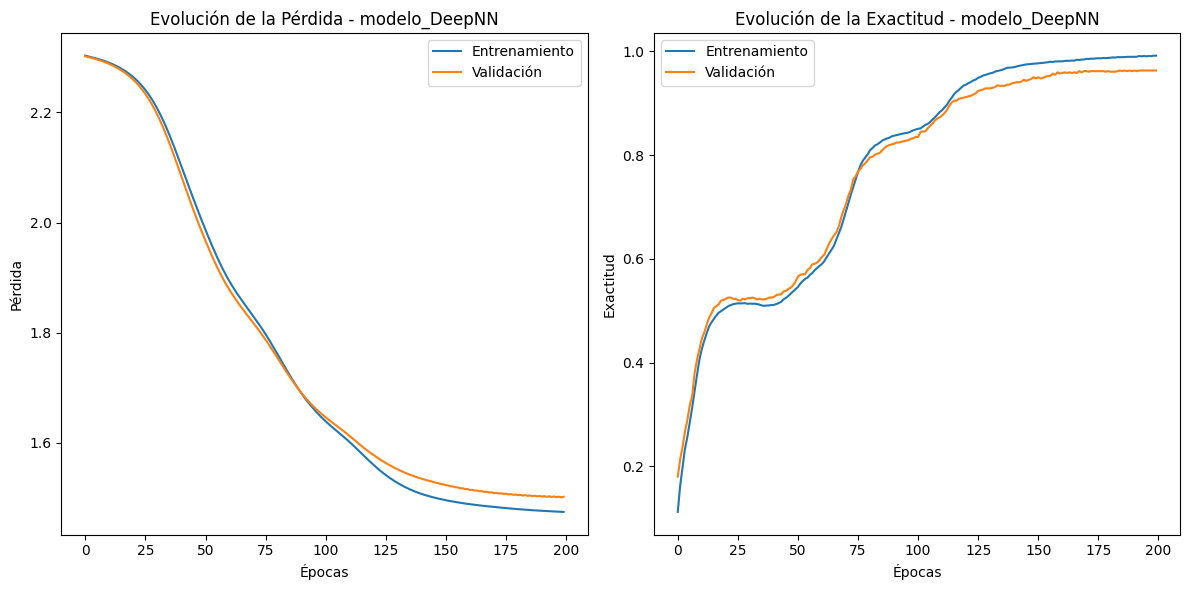

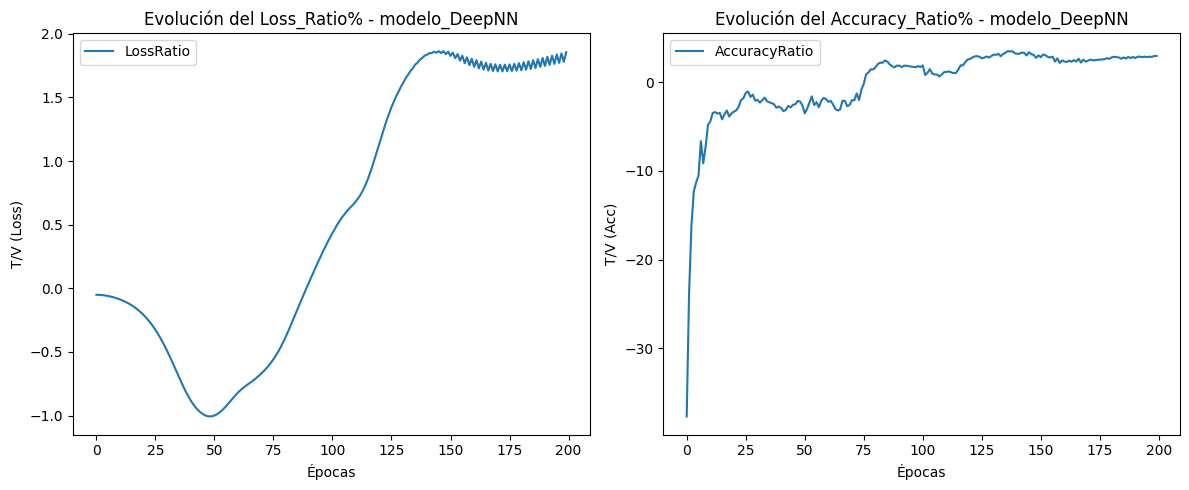

In [11]:
model = DeepNN(64,100,10).to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.RMSprop(model.parameters(), lr=0.0005, alpha=.07)
#optimizer = optim.SGD(model.parameters(), lr=0.15, momentum=0.7) 
#optimizer = optim.Adam(model.parameters(), lr=0.0001)
#optimizer = optim.RMSprop(model_dnn2.parameters(), lr=0.0005, alpha=.07)
#optimizer = optim.Adagrad(model_dnn2.parameters(), lr=0.004)
SD_tmodel,tlh,vlh,tah,vah = Train_Validate(model, criterion, optimizer, 200)
Evalua(model,SD_tmodel,criterion)
#Evalua1(model,criterion)
Grafica_LossAcc(tlh,vlh,tah,vah,'modelo_DeepNN')
Grafica_RatiosTV(tlh,vlh,tah,vah,'modelo_DeepNN')

## FAse 2
### Implementación de un Autoencoder para la Detección y Eliminación de Datos Anómalos

##### Objetivo: 
Construir y entrenar un autoencoder para identificar y eliminar datos anómalos del conjunto de datos Optdigits.


Un autoencoder es una red neuronal diseñada para aprender una representación compacta de los datos. Consiste en dos partes:

***Codificador:*** Reduce la dimensionalidad de los datos, comprimiéndolos en una representación más pequeña.

***Decodificador***: Reconstruye los datos originales a partir de la representación comprimida.

##### Paso 1
Vamos a construir un autoencoder con capas simétricas 64 - 32 - 16. La idea es que el autoencoder aprenda a reconstruir las imágenes de dígitos normales, pero tendrá dificultades para reconstruir imágenes de dígitos anómalos, resultando en un mayor error de reconstrucción. En este caso resulta ser más práctico usar el optimizador Adam y una función de perdida de el error cuadrático medio. Esta metrica resulta conveniente dada la tarea de reconstrucción porque queremos minimizar la diferencia entre la entrada original y la salida reconstruida.

In [12]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.PReLU(),
            nn.Linear(32, 16),
            nn.PReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.PReLU(),
            nn.Linear(32, 64),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Crear el autoencoder y moverlo a la GPU
autoencoder = Autoencoder().to(device)
autoencoder_criterion = nn.MSELoss() #Error cuadrático medio
autoencoder_optimizer = optim.Adam(autoencoder.parameters(), lr=0.001) #Optimizador ADAM

##### PAso 2: Entrenamos el autoencoder para que aprenda a reconstruir los datos de entrenamiento.

Epoch 1/1000, Loss: 1.2137
Epoch 2/1000, Loss: 1.2125
Epoch 3/1000, Loss: 1.2113
Epoch 4/1000, Loss: 1.2101
Epoch 5/1000, Loss: 1.2089
Epoch 6/1000, Loss: 1.2077
Epoch 7/1000, Loss: 1.2065
Epoch 8/1000, Loss: 1.2052
Epoch 9/1000, Loss: 1.2039
Epoch 10/1000, Loss: 1.2026
Epoch 11/1000, Loss: 1.2013
Epoch 12/1000, Loss: 1.1999
Epoch 13/1000, Loss: 1.1985
Epoch 14/1000, Loss: 1.1970
Epoch 15/1000, Loss: 1.1955
Epoch 16/1000, Loss: 1.1939
Epoch 17/1000, Loss: 1.1922
Epoch 18/1000, Loss: 1.1905
Epoch 19/1000, Loss: 1.1887
Epoch 20/1000, Loss: 1.1868
Epoch 21/1000, Loss: 1.1848
Epoch 22/1000, Loss: 1.1827
Epoch 23/1000, Loss: 1.1805
Epoch 24/1000, Loss: 1.1782
Epoch 25/1000, Loss: 1.1758
Epoch 26/1000, Loss: 1.1732
Epoch 27/1000, Loss: 1.1706
Epoch 28/1000, Loss: 1.1677
Epoch 29/1000, Loss: 1.1648
Epoch 30/1000, Loss: 1.1616
Epoch 31/1000, Loss: 1.1583
Epoch 32/1000, Loss: 1.1549
Epoch 33/1000, Loss: 1.1512
Epoch 34/1000, Loss: 1.1474
Epoch 35/1000, Loss: 1.1434
Epoch 36/1000, Loss: 1.1392
E

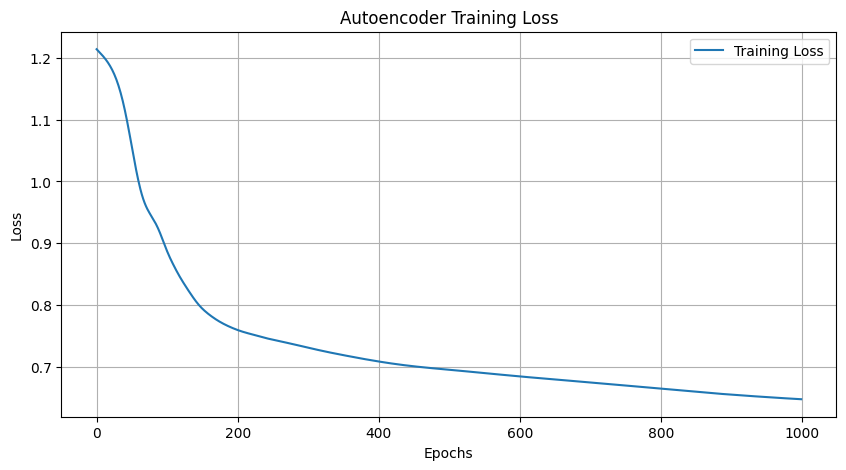

In [13]:
def Train_Autoencoder(autoencoder, criterion, optimizer, epochs):
    train_loss_history = []

    for epoch in range(epochs):
        autoencoder.train()
        optimizer.zero_grad()
        outputs = autoencoder(X_train)
        loss = criterion(outputs, X_train)
        train_loss_history.append(loss.item())
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

    return train_loss_history

def Plot_Loss(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Entrenar el autoencoder
autoencoder_loss_history = Train_Autoencoder(autoencoder, autoencoder_criterion, autoencoder_optimizer, epochs=1000)
# Graficar la función de pérdida del autoencoder
Plot_Loss(autoencoder_loss_history, 'Autoencoder Training Loss')

##### Paso 3: Detectar y Eliminar Datos Anómalos
Una vez entrenado el autoencoder, calculamos el error de reconstrucción para cada dato. Si el error es mayor que un umbral predefinido, consideramos el dato como anómalo.

In [18]:
def Detect_Anomalies(autoencoder, data, threshold):
    autoencoder.eval()
    with torch.no_grad():
        reconstructed = autoencoder(data)
        reconstruction_error = torch.mean((data - reconstructed) ** 2, dim=1)
    anomalies = reconstruction_error > threshold
    return anomalies, reconstruction_error, reconstructed

# Detectar anomalías en el conjunto de entrenamiento
anomalies, reconstruction_error, reconstructed_data = Detect_Anomalies(autoencoder, X_train, threshold=0.02)

# Eliminar datos anómalos del conjunto de entrenamiento
X_train_clean = X_train[~anomalies]
y_train_clean = y_train[~anomalies]

 - Visualización de las Anomalías
 
Vamos a visualizar algunas de las anomalías detectadas comparando las imágenes originales con sus reconstrucciones

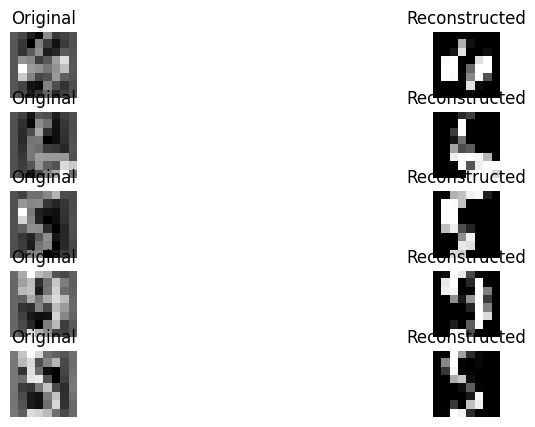

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_anomalies(original_data, reconstructed_data, anomalies, num_anomalies=5):
    # Seleccionar los índices de las anomalías
    anomaly_indices = np.where(anomalies.cpu().numpy())[0]
    if len(anomaly_indices) < num_anomalies:
        num_anomalies = len(anomaly_indices)
    
    plt.figure(figsize=(10, 5))
    for i in range(num_anomalies):
        idx = anomaly_indices[i]
        
        # Original Image
        plt.subplot(num_anomalies, 2, 2*i+1)
        plt.imshow(original_data[idx].cpu().numpy().reshape(8, 8), cmap='gray')
        plt.title("Original")
        #plt.axis('off')
        
        # Reconstructed Image
        plt.subplot(num_anomalies, 2, 2*i+2)
        plt.imshow(reconstructed_data[idx].cpu().numpy().reshape(8, 8), cmap='gray')
        plt.title("Reconstructed")
        #plt.axis('off')
    
    plt.show()

# Visualizar algunas de las anomalías
visualize_anomalies(X_train, reconstructed_data, anomalies)

##### Paso 5: Evaluar el Modelo Mejorado
Entrenamos de nuevo el modelo de clasificación utilizando el conjunto de datos purgado de anomalías y evaluamos su rendimiento

ENTRENAMIENTO ->>> Epoch 200/200. Loss: 1.4663,  Accuracy: 0.9962
EVALUACION ->>> Test Loss: 1.4891, Test Accuracy: 0.9763


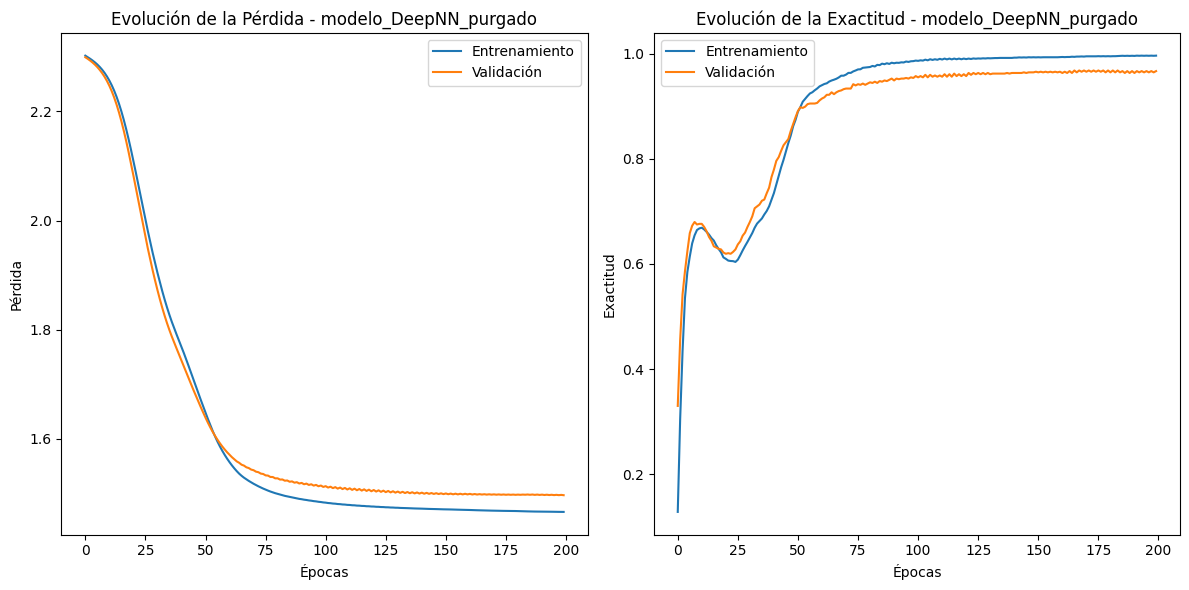

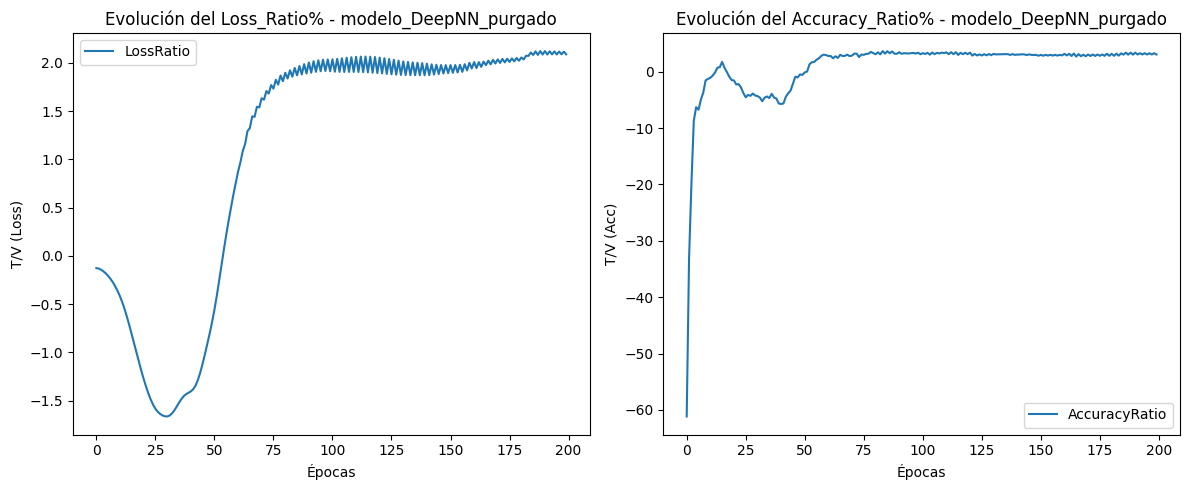

In [15]:
# Crear un nuevo modelo de clasificación y entrenarlo con los datos purgados
model_clean = DeepNN(64,200,10).to(device)
criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model_clean.parameters(), lr=0.0001)
optimizer = optim.RMSprop(model_clean.parameters(), lr=0.0005, alpha=.07)


# Entrenar el modelo purgado
SD_tmodel_clean, tlh_clean, vlh_clean, tah_clean, vah_clean = Train_Validate(model_clean, criterion, optimizer, epochs=200)

# Evaluación del modelo purgado
#Evalua1(model_clean, criterion)
Evalua(model_clean,SD_tmodel_clean,criterion)

# Graficar las métricas del modelo purgado
Grafica_LossAcc(tlh_clean, vlh_clean, tah_clean, vah_clean, 'modelo_DeepNN_purgado')
Grafica_RatiosTV(tlh_clean, vlh_clean, tah_clean, vah_clean, 'modelo_DeepNN_purgado')

### Resultados

**Resultados para los datos con anomalías** 

ENTRENAMIENTO ->>> Epoch 200/200. Loss: 1.4749,  Accuracy: 0.9919
EVALUACION ->>> Test Loss: 1.5060, Test Accuracy: 0.9597

**Resultados de los datos limpios después de *purgarlos* en el Auto-Encoder**

ENTRENAMIENTO ->>> Epoch 200/200. Loss: 1.4663,  Accuracy: 0.9962
EVALUACION ->>> Test Loss: 1.4891, Test Accuracy: 0.9763

### Conclusiones

**1ra fase**
- Los resultados son buenos desde la primera fase con una precisión en la prueba de 95.97% casi 96%. 

- La arquitectura propuesta resultó efectiva.

**2da fase**

- El autoencoder se diseño de una forma simple con solo tres capas de cada lado (Codificación y Decodificación)

- En este caso se usó una función de pérdida del error cuadrático medio que resulta coveniente y el optimizador ADAM dada la naturaleza del Autoencoder.

- Notamos que su función de pérdida  disminuye notablemente. 

- Una curva que desciende de manera constante sugiere que el autoencoder está aprendiendo y mejorando en la reconstrucción de los datos de entrada.

**3era fase**

- Notamos que bajo las mimas condiciones las métricas se ven con curvas más suaves, menos accidentadas. 

- Lo anterior muestra un entrenamiento más fluido y eficiente con respecto al entrenamiento con datos anómalos.

- A pesar de los buenos resultados de la primera fase, los resultados de la tercera fase con datos purgados resulto mejor obteniendo una precición en los datos de prueba de 97.63%